In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,average_precision_score,roc_auc_score,confusion_matrix
from xgboost import XGBClassifier
import shap

c:\Users\Mikey\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
file_path=r"C:\Users\Mikey\Desktop\Project\Project_file_1.csv"
df=pd.read_csv(file_path)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df_1=df.copy()

In [5]:
df['poutcome'].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [6]:
mapping_1=({'yes':1,'no':0})
df['y']=df['y'].map(mapping_1)

In [7]:
df['previously_contacted']=np.where(df['pdays']>=0,1,0)

In [8]:
df=df.drop(columns=['duration'])

In [9]:
df.columns.to_list()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y',
 'previously_contacted']

In [10]:
categorical_cols=['job','marital','education','default','housing','loan','month','poutcome','contact']
X=df.drop(columns=['y'])
Y=df['y']

In [11]:
X=pd.get_dummies(X,columns=categorical_cols,drop_first=True)

In [12]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,stratify=Y,test_size=0.25,random_state=42)

In [13]:
print("Train_positive_rate:",round(Y_train.mean(),3))
print("Test_positive_rate:",round(Y_test.mean(),3))

Train_positive_rate: 0.117
Test_positive_rate: 0.117


In [14]:
df.columns.to_list()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y',
 'previously_contacted']

In [15]:
numerical_col=['age','balance','day','campaign','previous','pdays']

In [16]:
scaler=StandardScaler()
X_train_scaled=X_train.copy()
X_test_scaled=X_test.copy()
X_train_scaled[numerical_col]=scaler.fit_transform(X_train[numerical_col])
X_test_scaled[numerical_col]=scaler.transform(X_test[numerical_col])

In [17]:
log_model=LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)
log_model.fit(X_train_scaled,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [18]:
log_prob=log_model.predict_proba(X_test_scaled)[:,1]

In [19]:
print("ROC-AUC:", round(roc_auc_score(Y_test, log_prob), 4))
print("PR-AUC:", round(average_precision_score(Y_test, log_prob), 4))

ROC-AUC: 0.7731
PR-AUC: 0.416


In [20]:
logreg_pred = (log_prob >= 0.5).astype(int)
print(classification_report(Y_test, logreg_pred, target_names=["no", "yes"]))

              precision    recall  f1-score   support

          no       0.94      0.77      0.84      9981
         yes       0.26      0.64      0.37      1322

    accuracy                           0.75     11303
   macro avg       0.60      0.70      0.61     11303
weighted avg       0.86      0.75      0.79     11303



In [21]:
confusion_matrix(Y_test,logreg_pred)

array([[7647, 2334],
       [ 481,  841]])

In [22]:
scale_pos_weight = (Y_train == 0).sum() / (Y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

scale_pos_weight: 7.55


In [23]:
xgboost = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)
xgboost.fit(X_train, Y_train)

xgb_proba = xgboost.predict_proba(X_test)[:, 1]

In [24]:
print("ROC-AUC:", round(roc_auc_score(Y_test, xgb_proba), 4))
print("PR-AUC:", round(average_precision_score(Y_test, xgb_proba), 4))

ROC-AUC: 0.8015
PR-AUC: 0.4615


In [25]:
xgb_pred=(xgb_proba>=0.5).astype(int)
print(classification_report(Y_test,xgb_pred,target_names=["no","yes"]))

              precision    recall  f1-score   support

          no       0.95      0.83      0.89      9981
         yes       0.34      0.65      0.45      1322

    accuracy                           0.81     11303
   macro avg       0.64      0.74      0.67     11303
weighted avg       0.88      0.81      0.84     11303



In [26]:
confusion_matrix(Y_test,xgb_pred)

array([[8327, 1654],
       [ 463,  859]])

In [27]:
explainer=shap.TreeExplainer(xgboost)

In [28]:
shap_values=explainer.shap_values(X_test)

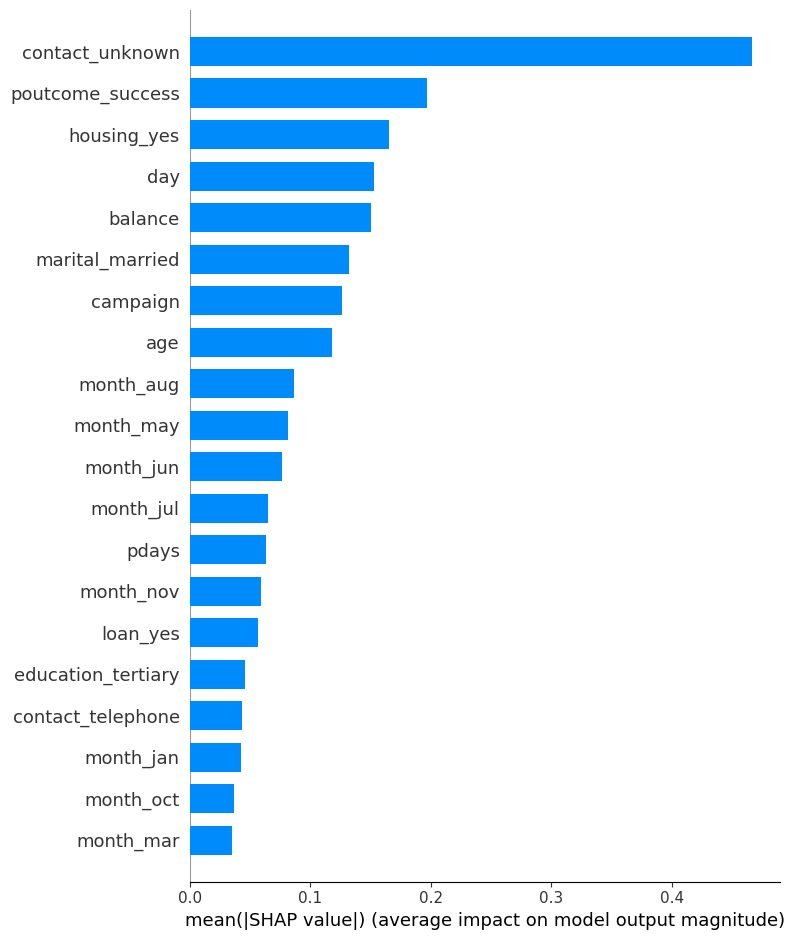

In [29]:
shap.summary_plot(shap_values,X_test,plot_type='bar')

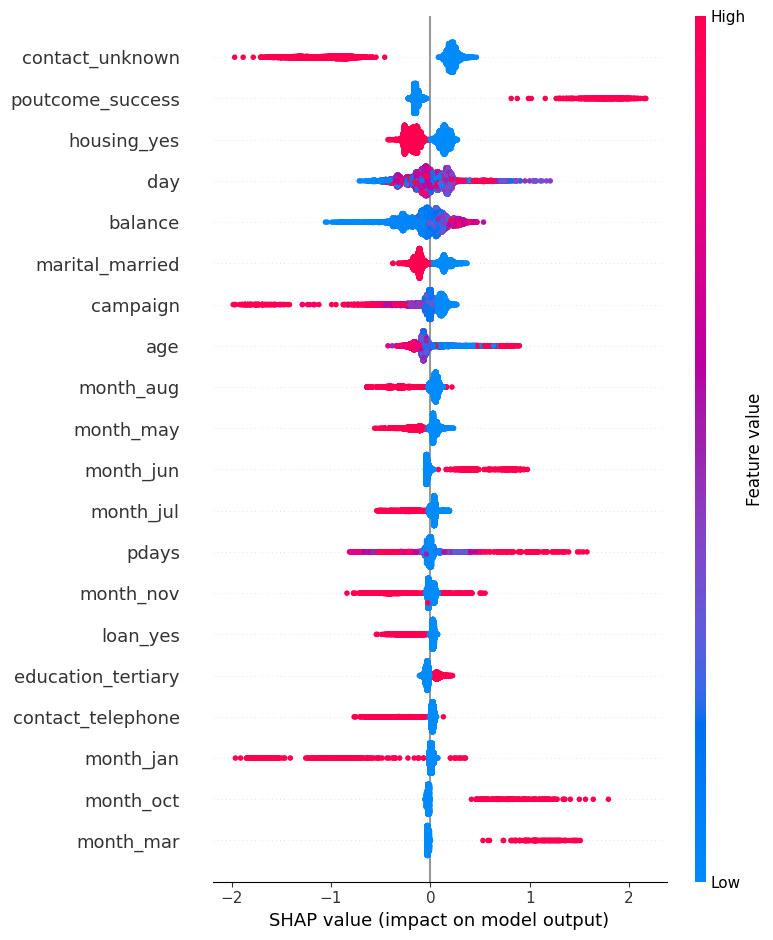

In [30]:
shap.summary_plot(shap_values,X_test)

In [31]:
shap.initjs()

In [32]:
shap.force_plot(explainer.expected_value,shap_values[15],X_test.iloc[15])

In [33]:
campaign=X_test.copy()
campaign['predicted_prob']=xgb_proba
campaign=campaign.sort_values('predicted_prob',ascending=False)
campaign.head()

,age,balance,day,campaign,pdays,previous,previously_contacted,job_blue-collar,job_entrepreneur,job_housemaid,...,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,contact_telephone,contact_unknown,predicted_prob
43122,20,215,24,1,92,6,1,False,False,False,...,False,False,False,False,False,True,False,False,False,0.991292
43165,28,1925,26,1,93,3,1,False,False,False,...,False,False,False,False,False,True,False,False,False,0.986572
43135,25,469,24,1,187,2,1,False,False,False,...,False,False,False,False,False,True,False,False,False,0.985735
43164,30,5359,26,1,191,3,1,False,False,False,...,False,False,False,False,False,True,False,False,False,0.985216
43215,68,2820,5,1,92,3,1,False,False,False,...,False,False,False,False,False,True,False,False,False,0.979990


In [34]:
campaign_df=pd.DataFrame()
campaign_df['predicted_prob']=campaign['predicted_prob']
campaign_df['Actual_event']=Y_test.values

In [35]:
revenue_per_success=500
cost=20

In [36]:
campaign_df['expected_revenue'] = (campaign_df['predicted_prob'] * revenue_per_success).astype(int)
campaign_df['expected_profit']=(campaign_df['expected_revenue']-cost).astype(int)

In [37]:
campaign_df['ROI']=campaign_df['expected_profit']/cost
campaign_df.head()

,predicted_prob,Actual_event,expected_revenue,expected_profit,ROI
43122,0.991292,0,495,475,23.75
43165,0.986572,0,493,473,23.65
43135,0.985735,0,492,472,23.60
43164,0.985216,0,492,472,23.60
43215,0.979990,0,489,469,23.45


In [38]:
scenarios = [0.05, 0.10, 0.20, 0.30, 0.50, 1.00]

In [39]:
scenario_budget=[50000,100000,150000,200000]
budget_df=[]
for budget in scenario_budget:
    target_customers=int(budget/cost)
    target_df=campaign_df.head(target_customers)
    expected_rev=target_df['expected_revenue'].sum()
    expected_profit_b=target_df['expected_profit'].sum()
    roi_b=expected_profit_b/budget

    budget_df.append({
        'Budget':budget,
        'Target_customers':target_customers,
        'Expected_revenue':expected_rev,
        'Expected_profit':expected_profit_b,
        'ROI':roi_b
    })


In [40]:
scenario_budget_df=pd.DataFrame(budget_df)
scenario_budget_df

,Budget,Target_customers,Expected_revenue,Expected_profit,ROI
0,50000,2500,881691,831691,16.63382
1,100000,5000,1410480,1310480,13.10480
2,150000,7500,1799847,1649847,10.99898
3,200000,10000,2071332,1871332,9.35666


In [42]:
scenario_budget_df.to_excel("scenario_budget.xlsx",index=False)

In [44]:
scenario_results = []

for share in scenarios:
    
    n_customers = int(len(campaign_df) * share)
    
    targeted = campaign_df.head(n_customers)
    
    expected_revenue = targeted['expected_revenue'].sum()
    campaign_cost = n_customers * cost
    expected_profit = expected_revenue - campaign_cost
    roi = expected_profit / campaign_cost
    
    scenario_results.append({
        'target_share': share,
        'customers_targeted': n_customers,
        'expected_revenue': expected_revenue,
        'campaign_cost': campaign_cost,
        'expected_profit': expected_profit,
        'ROI': roi
    })

In [45]:
scenario_df = pd.DataFrame(scenario_results)

scenario_df

,target_share,customers_targeted,expected_revenue,campaign_cost,expected_profit,ROI
0,0.05,565,258648,11300,247348,21.889204
1,0.10,1130,480247,22600,457647,20.249867
2,0.20,2260,820343,45200,775143,17.149181
3,0.30,3390,1090352,67800,1022552,15.081888
4,0.50,5651,1523126,113020,1410106,12.476606
5,1.00,11303,2153953,226060,1927893,8.528236


In [46]:
scenario_df.to_excel("scenario_df.xlsx",index=False)

In [60]:
from catboost import CatBoostClassifier

In [61]:
X_cat=df_1.drop(columns=['y'])
X_cat=X_cat.drop(columns=['duration'])

In [62]:
X_cat['was_called_previously']=np.where(X_cat['pdays']>0,1,0)

In [63]:
Y_cat=np.where(df_1['y']=='no',0,1)

In [64]:
X_train_cat,X_test_cat,Y_train_cat,Y_test_cat=train_test_split(X_cat,Y_cat,test_size=0.25,random_state=42,stratify=Y_cat)

In [65]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

In [66]:
df.columns.to_list()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y',
 'previously_contacted']

In [67]:
cat_feature=['job','marital','education','default','housing','loan','month','poutcome','contact']

In [68]:
cat_model.fit(X_train_cat,Y_train_cat,cat_features=cat_feature,eval_set=(X_test_cat,Y_test_cat),early_stopping_rounds=50)

0:	test: 0.6226365	best: 0.6226365 (0)	total: 267ms	remaining: 2m 13s
100:	test: 0.7875841	best: 0.7876325 (98)	total: 8.79s	remaining: 34.7s
200:	test: 0.7947338	best: 0.7947519 (192)	total: 18.2s	remaining: 27.1s
300:	test: 0.7989223	best: 0.7989223 (300)	total: 26.3s	remaining: 17.4s
400:	test: 0.8003590	best: 0.8004069 (399)	total: 34.6s	remaining: 8.55s
499:	test: 0.8014796	best: 0.8014796 (498)	total: 42.6s	remaining: 0us

bestTest = 0.8014796191
bestIteration = 498

Shrink model to first 499 iterations.


CatBoostClassifier(depth=4, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [69]:
cat_prob=cat_model.predict_proba(X_test_cat)[:,1]

In [70]:
cat_prob_model=(cat_prob>=0.5).astype(int)
print(classification_report(Y_test_cat,cat_prob_model,target_names=['no','yes']))

              precision    recall  f1-score   support

          no       0.91      0.98      0.94      9981
         yes       0.66      0.23      0.34      1322

    accuracy                           0.90     11303
   macro avg       0.78      0.61      0.64     11303
weighted avg       0.88      0.90      0.87     11303



In [71]:
print(round(roc_auc_score(Y_test_cat,cat_prob),3))
print(round(average_precision_score(Y_test_cat,cat_prob),3))

0.801
0.461


In [72]:
print(confusion_matrix(Y_test_cat,cat_prob_model))

[[9825  156]
 [1019  303]]
